## 시퀀스 배열로 다루는 순환 신경망(RNN)

### LSTM을 이용한 로이터 뉴스 카테고리 분류하기


In [ ]:
# -----------------------------------------
# 1️⃣ 딥러닝과 데이터 처리에 필요한 도구들 불러오기
# -----------------------------------------

# 신경망 모델을 만들기 위한 기본 틀
from tensorflow.keras.models import Sequential

# 신경망의 층들
# Dense  → 최종 분류용 일반 신경망
# LSTM   → 문장의 흐름을 기억하는 신경망
# Embedding → 단어를 의미 벡터로 바꿔주는 층
from tensorflow.keras.layers import Dense,LSTM,Embedding

# 정답(카테고리)을 원-핫 형식으로 바꿀 때 사용
from tensorflow.keras.utils import to_categorical

# 문장 길이를 맞출 때 사용하는 도구
from tensorflow.keras.preprocessing import sequence

# 로이터 뉴스 데이터셋 불러오기
from tensorflow.keras.datasets import reuters

# 학습을 너무 오래 하지 않도록 자동으로 멈추는 기능
from tensorflow.keras.callbacks import EarlyStopping


# -----------------------------------------
# 2️⃣ 숫자 계산과 그래프를 위한 라이브러리
# -----------------------------------------
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------------------
# 3️⃣ 로이터 뉴스 데이터 불러오기
# -----------------------------------------
# num_words=1000 → 가장 많이 쓰인 단어 1000개만 사용
# test_split=0.2 → 전체 데이터의 20%를 테스트용으로 사용
(X_train,y_train),(X_test,y_test)=reuters.load_data(num_words=1000,test_split=0.2)


# X_train → 학습용 뉴스 기사(단어 번호로 된 문장들)
# y_train → 각 뉴스의 주제 번호
# X_test  → 테스트용 뉴스 기사
# y_test  → 테스트용 정답


# -----------------------------------------
# 4️⃣ 뉴스 주제(카테고리) 개수 계산
# -----------------------------------------
# y_train에는 0,1,2,... 같은 숫자로 주제가 들어 있음
# 가장 큰 번호 + 1 → 전체 주제 개수
category=np.max(y_train) +1

# -----------------------------------------
# 5️⃣ 데이터 정보 출력
# -----------------------------------------

# 뉴스 주제가 몇 개인지 출력
print(category,'카테고리')
# 학습용 뉴스 기사 개수 출력
print(len(X_train),'학습용 뉴스 기사')
# 테스트용 뉴스 기사 개수 출력
print(len(X_test),'테스트용 뉴스 기사')

# 첫 번째 뉴스 기사 출력
# 하지만 문장이 아니라 단어 번호들의 리스트로 나옴
print(X_train[0])

46 카테고리
8982 학습용 뉴스 기사
2246 테스트용 뉴스 기사
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [ ]:
# -----------------------------------------
# 1️⃣ 뉴스 기사 길이 맞추기 (Padding)
# -----------------------------------------
# 뉴스 기사마다 단어 개수가 다 다르기 때문에
# LSTM에 넣으려면 길이를 똑같이 만들어야 함
# 모든 문장을 길이 100으로 맞춤

X_train=sequence.pad_sequences(X_train,maxlen=100)
X_test=sequence.pad_sequences(X_test,maxlen=100)


# -----------------------------------------
# 2️⃣ 정답(카테고리)을 원-핫 벡터로 변환
# -----------------------------------------
# y_train과 y_test에는
# 0 ~ 45 사이의 숫자로 뉴스 주제가 들어 있음
# 이를 딥러닝이 계산할 수 있도록
# 46칸짜리 0/1 벡터로 변환
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)


# -----------------------------------------
# 3️⃣ 신경망 모델 만들기
# -----------------------------------------
# Sequential → 층을 차례대로 쌓는 모델
model=Sequential()

# -----------------------------------------
# 4️⃣ Embedding 층
# -----------------------------------------
# 단어 번호(0~999)를
# 100개의 숫자로 된 의미 벡터로 바꿈
# → 단어를 컴퓨터가 이해할 수 있는 형태로 변환
model.add(Embedding(1000,100))

# -----------------------------------------
# 5️⃣ LSTM 층
# -----------------------------------------
# 문장을 앞에서부터 읽으면서
# 중요한 내용을 기억하는 신경망
# 100개의 기억 공간(노드)을 사용
model.add(LSTM(100,activation='tanh'))


# -----------------------------------------
# 6️⃣ 출력층
# -----------------------------------------
# 뉴스 주제는 46개이므로
# 46개 중 하나를 선택하도록 설정
# softmax → 각 주제일 확률을 계산
model.add(Dense(46,activation='softmax'))


# -----------------------------------------
# 7️⃣ 모델 학습 방법 설정
# -----------------------------------------
# categorical_crossentropy → 여러 개 중 하나 고르는 문제에 사용
# adam → 학습을 자동으로 잘 조절해 주는 최적화 방법
# accuracy → 맞춘 비율(정확도)을 출력
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])



# -----------------------------------------
# 8️⃣ Early Stopping 설정
# -----------------------------------------
# 검증 데이터(val_loss)가
# 5번 연속 좋아지지 않으면
# 자동으로 학습을 멈춤
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=5)


# -----------------------------------------
# 9️⃣ 모델 학습
# -----------------------------------------
# X_train, y_train → 학습용 데이터
# batch_size=20 → 20개씩 묶어서 학습
# epochs=200 → 최대 200번 반복
# validation_data → 중간중간 시험 보는 데이터
# callbacks → EarlyStopping 적용
history=model.fit(X_train,y_train,batch_size=20,epochs=200,validation_data=(X_test,y_test),callbacks=[early_stopping_callback])


# -----------------------------------------
# 🔟 최종 테스트 정확도 출력
# -----------------------------------------
# 학습이 끝난 후
# 테스트 데이터로 성능 평가
print("\n Test Accuracy : %.4f" % (model.evaluate(X_test,y_test)[1]))

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.4497 - loss: 2.2111 - val_accuracy: 0.5165 - val_loss: 1.9947
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5502 - loss: 1.7782 - val_accuracy: 0.5695 - val_loss: 1.6803
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6013 - loss: 1.5769 - val_accuracy: 0.6006 - val_loss: 1.5691
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6496 - loss: 1.3798 - val_accuracy: 0.6549 - val_loss: 1.4006
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6971 - loss: 1.2102 - val_accuracy: 0.6741 - val_loss: 1.3053
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7325 - loss: 1.0774 - val_accuracy: 0.6941 - val_loss: 1.2284
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7634 - loss: 0.9656 - val_accuracy: 0.7070 - val_loss: 1.1754
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.7810 - loss: 0.8808 -

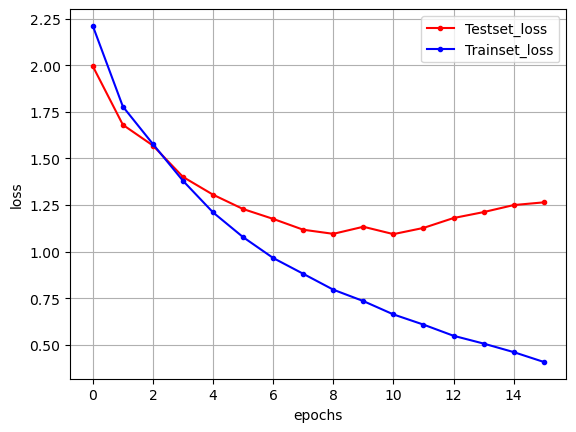

In [ ]:
# -----------------------------------------
# 1️⃣ 학습 중 기록된 손실값 가져오기
# -----------------------------------------
# history.history에는
# 모델이 학습하면서 기록한 값들이 들어 있음

# loss     → 학습용 데이터에서 얼마나 틀렸는지
# val_loss → 테스트(검증) 데이터에서 얼마나 틀렸는지
y_vloss=history.history['val_loss']
y_loss=history.history['loss']


# -----------------------------------------
# 2️⃣ x축(학습 횟수) 만들기
# -----------------------------------------
# y_loss의 길이 = 학습한 횟수(epochs)
# 예: 20번 학습 → [0,1,2,...,19]
x_len=np.arange(len(y_loss))


# -----------------------------------------
# 3️⃣ 테스트(검증) 데이터 손실 그래프
# -----------------------------------------
# 빨간색 점과 선으로
# 시험 데이터에서의 오차를 그림
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')

# -----------------------------------------
# 4️⃣ 학습(훈련) 데이터 손실 그래프
# -----------------------------------------
# 파란색 점과 선으로
# 학습 데이터에서의 오차를 그림
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')



# -----------------------------------------
# 5️⃣ 범례 표시
# -----------------------------------------
# 빨간색과 파란색이 무엇인지 설명 표시

plt.legend(loc='upper right')


# -----------------------------------------
# 6️⃣ 격자 표시
# -----------------------------------------
# 그래프를 보기 쉽게 격자 추가
plt.grid()

# -----------------------------------------
# 7️⃣ 축 이름 설정
# -----------------------------------------
# x축 → 학습 횟수
# y축 → 오차(loss)
plt.xlabel('epochs')
plt.ylabel('loss')

# -----------------------------------------
# 8️⃣ 그래프 화면에 출력
# -----------------------------------------
plt.show()

## LSTM과 CNN의 조합을 이용한 영화 리뷰 분류하기


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Embedding,LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=5000)

X_train=sequence.pad_sequences(X_train,maxlen=500)
X_test=sequence.pad_sequences(X_test,maxlen=500)

model=Sequential()
model.add(Embedding(5000,100))
model.add(Dropout(0.5))
model.add(Conv1D(64,5,padding='valid',activation='relu',strides=1))
model.add(MaxPooling1D(pool_size=4))
model.add(LSTM(55))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.build(input_shape=(None,100))
model.summary()



17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 55)             │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,520 (2.13 MB)

 Trainable params: 558,520 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


early_stopping_callback=EarlyStopping(monitor='val_loss',patience=3)


history=model.fit(X_train,
                  y_train,
                  batch_size=40,
                  epochs=100,
                  validation_split=0.25,
                  callbacks=[early_stopping_callback])

print('\n Test Accuracy: %.4f' % (model.evaluate(X_test,y_test)[1]))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8031 - loss: 0.4073 - val_accuracy: 0.8877 - val_loss: 0.2783
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9065 - loss: 0.2358 - val_accuracy: 0.8960 - val_loss: 0.2502
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9314 - loss: 0.1829 - val_accuracy: 0.8917 - val_loss: 0.2683
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9448 - loss: 0.1484 - val_accuracy: 0.8922 - val_loss: 0.2820
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9591 - loss: 0.1165 - val_accuracy: 0.8910 - val_loss: 0.3254
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8830 - loss: 0.3433

 Test Accuracy: 0.8830
